In [1]:
import pandas as pd
import featuretools as ft
from featuretools.primitives import Day, Weekday, IsWeekend, Hour, Mean, Sum, Count, Max, Std, Skew
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2026-03-01 15:26:47,411 featuretools - WARNING    While loading primitives via "nlp_primitives" entry point, ignored primitive "DiversityScore" from "nlp_primitives.diversity_score" because a primitive with that name already exists in "premium_primitives.diversity_score"
2026-03-01 15:26:47,412 featuretools - WARNING    While loading primitives via "nlp_primitives" entry point, ignored primitive "LSA" from "nlp_primitives.lsa" because a primitive with that name already exists in "premium_primitives.lsa"
2026-03-01 15:26:47,413 featuretools - WARNING    While loading primitives via "nlp_primitives" entry point, ignored primitive "MeanCharactersPerSentence" from "nlp_primitives.mean_characters_per_sentence" because a primitive with that name already exists in "premium_primitives.mean_characters_per_sentence"
2026-03-01 15:26:47,413 featuretools - WARNING    While loading primitives via "nlp_primitives" entry point, ignored primitive "NumberOfSentences" from "nlp_primitives.number_of_sent

In [2]:
users_df = pd.read_csv('../Final/users.csv')
accounts_df = pd.read_csv('../Final/accounts.csv')
transactions_df = pd.read_csv('../Final/transactions.csv')
monthly_stats_df = pd.read_csv('../analytics/user_monthly_stats.csv')
all_time_stats_df = pd.read_csv('../analytics/user_all_time_stats.csv')

def expand_json_categories(df, column_name):
    json_as_df = df[column_name].apply(lambda x: json.loads(x.replace("'", '"')) if isinstance(x, str) else x).apply(pd.Series)
    json_as_df = json_as_df.fillna(0)
    return pd.concat([df.drop(columns=[column_name]), json_as_df], axis=1)

transactions_df['date'] = pd.to_datetime(transactions_df['date'])
monthly_stats_df['month_start_date'] = pd.to_datetime(monthly_stats_df['month_start_date'])
monthly_stats_df = expand_json_categories(monthly_stats_df, 'spending_by_category')

es = ft.EntitySet(id="financial__system")

In [3]:
es.add_dataframe(dataframe_name="users", dataframe=users_df, index="user_id")

es.add_dataframe(dataframe_name="accounts", dataframe=accounts_df, index="account_id")

es.add_dataframe(dataframe_name="transactions", dataframe=transactions_df, 
                 index="transaction_id", time_index="date")

es.add_dataframe(dataframe_name="monthly_stats", dataframe=monthly_stats_df, 
                 index="stats_id", time_index="month_start_date")

es.add_dataframe(dataframe_name="all_time_stats", dataframe=all_time_stats_df, index="stats_id")

es.add_relationship("accounts", "account_id", "users", "account_id")
es.add_relationship("accounts", "account_id", "transactions", "account_id")
es.add_relationship("accounts", "account_id", "monthly_stats", "account_id")
es.add_relationship("accounts", "account_id", "all_time_stats", "account_id")

/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/woodwork/type_sys/utils.py:33

Entityset: financial__system
  DataFrames:
    users [Rows: 388, Columns: 9]
    accounts [Rows: 388, Columns: 7]
    transactions [Rows: 22602, Columns: 10]
    monthly_stats [Rows: 5880, Columns: 28]
    all_time_stats [Rows: 306, Columns: 6]
  Relationships:
    users.account_id -> accounts.account_id
    transactions.account_id -> accounts.account_id
    monthly_stats.account_id -> accounts.account_id
    all_time_stats.account_id -> accounts.account_id

# Time-Based Amount Features

In [4]:
trans_primitives = [Day, Weekday, IsWeekend]
agg_primitives = [Mean, Sum, Count, Max, Std]

feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="users",
    trans_primitives=trans_primitives,
    agg_primitives=agg_primitives,
    max_depth=2,
    verbose=True
)

numeric_cols = feature_matrix.select_dtypes(include=[np.number]).columns
feature_matrix[numeric_cols] = feature_matrix[numeric_cols].fillna(0)

/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/featuretools/synthesis/dfs.py:321: UnusedPrimitiveWarning: Some specified primitives were not used during DFS:
  trans_primitives: ['day', 'is_weekend', 'weekday']
This may be caused by a using a value of max_depth that is too small, not setting interesting values, or it may indicate no compatible columns for the primitive were found in the data. If the DFS call contained multiple instances of a primitive in the list above, none of them were used.
  warnings.warn(warning_msg, UnusedPrimitiveWarning)


Built 129 features
Elapsed: 00:00 | Progress:   0%|          

/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/featuretools/computational_backends/feature_set_calculator.py:781: FutureWarning: The provided callable <function max at 0x7ad599a325e0> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  to_merge = base_frame.groupby(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/featuretools/computational_backends/feature_set_calculator.py:781: FutureWarning: The provided callable <function std at 0x7ad599a37040> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  to_merge = base_frame.groupby(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/featuretools/computational_backends/feature_set_calculator.py:781: FutureWarning: The provided callable <function me

Elapsed: 00:00 | Progress: 100%|██████████


/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/featuretools/computational_backends/feature_set_calculator.py:781: FutureWarning: The provided callable <function mean at 0x7ad599a32ee0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  to_merge = base_frame.groupby(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/featuretools/computational_backends/feature_set_calculator.py:781: FutureWarning: The provided callable <function std at 0x7ad599a37040> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  to_merge = base_frame.groupby(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/featuretools/computational_backends/feature_set_calculator.py:781: FutureWarning: The provided callable <function

#### Remove Redundant Features - Feature Selection

SUM and MEAN are simmilar so that it can make noise if account has only one transaction.

Steps are:
1. Create a correlation matrix.
1. Select the upper triangle of the correlation matric
1. Identify columns with correlation higher than 0.95

In [5]:
corr_matrix = feature_matrix.corr(numeric_only=True).abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Dropping {len(to_drop)} highly correlated features.")
feature_matrix_reduced = feature_matrix.drop(columns=to_drop)

Dropping 62 highly correlated features.


#### Encode Categorical Data

Encode categorical features

1. Identify which features actually remain in your reduced matrix
1. Encode using ONLY the definitions that still exist
1. Limits one-hot encoding to top 10 categories to prevent "column explosion"

In [6]:
remaining_features = [
    f for f in feature_defs 
    if any(name in feature_matrix_reduced.columns for name in f.get_feature_names())
]

feature_matrix_reduced.ww.init()

fm_encoded, features_defs_encoded = ft.encode_features(
    feature_matrix_reduced, 
    remaining_features,
    top_n=10 
)

print(f"Final feature count after encoding: {fm_encoded.shape[1]}")

Final feature count after encoding: 106


/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/workspaces/python/env/featuretools-env/lib/python3.9/site-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


Filter columns to see your time-based amount features specifically

In [7]:
time_features = [col for col in fm_encoded.columns if any(t in col for t in ['DAY', 'WEEKDAY', 'WEEKEND'])]
display(fm_encoded[time_features].head())

""
user_id
USR601Ie
USR784ar
USR821Id
USR559Pi
USR200Qr


Test Feature Definition

> The Manual Table displays how featuretools assigned values for Day of month (DAY), Day of week (WEEKDAY), and if it is weekend (WEEKEND).

> THe Featuretools Result shows the UserIDs that are corespond to the transactions shown in the manual table.

In [8]:
sample_data = transactions_df[['date']].head(20).copy()

sample_data['manual_day'] = sample_data['date'].dt.day
sample_data['manual_weekday'] = sample_data['date'].dt.weekday
sample_data['manual_is_weekend'] = sample_data['date'].dt.weekday >= 5

print("Manual")
display(sample_data)

print("\nFeaturetools Result")
time_cols = [c for c in fm_encoded.columns if any(t in c for t in ['DAY', 'WEEKDAY', 'WEEKEND'])]
display(fm_encoded[time_cols].head(3))

Manual


,date,manual_day,manual_weekday,manual_is_weekend
0d4295e6-a72b-4731-b517-0ea76af6dfe3,2023-01-01,1,6,True
1e975023-780e-4629-ac7c-0a032491dec7,2023-01-01,1,6,True
224c9690-a539-4fda-9bcd-f7e6dc84db9e,2023-01-01,1,6,True
2e6cc1d3-21e4-4259-b9ba-76e12a5560c6,2023-01-01,1,6,True
3ce637b1-9eb8-4b63-bc24-6dbc4492abf1,2023-01-01,1,6,True
77da12ad-65f9-425b-961d-ccc2a1fb07d0,2023-01-01,1,6,True
96d8cc26-f485-4ddf-878d-cf78a611ae82,2023-01-01,1,6,True
98023efc-9efa-4d95-8b11-206a3cbc88e9,2023-01-01,1,6,True
dfab6c90-9135-442e-9118-b02442f45746,2023-01-01,1,6,True
0230b6c2-3d0f-459e-b098-0e1d62b8369d,2023-01-02,2,0,False



Featuretools Result


""
user_id
USR601Ie
USR784ar
USR821Id


Correlation Heatmap (all Transactions and all users together)

The diagram shows how different spending behaviors are linked across my entire user base.

The deep red/near 1.0 shows the same story like SUM(category) and MAX(category). It means that it is identifies as a redundant value.

The orange color represent lifecycle cluster. For example, Transportation costs are highly linked to Entertainment spending, showing that some of the users "go out" more frequently.

The blue color represent negative correlation/rare spending patterns. For example, if a user spends more on Housing, they might be spending more less on Trevel.

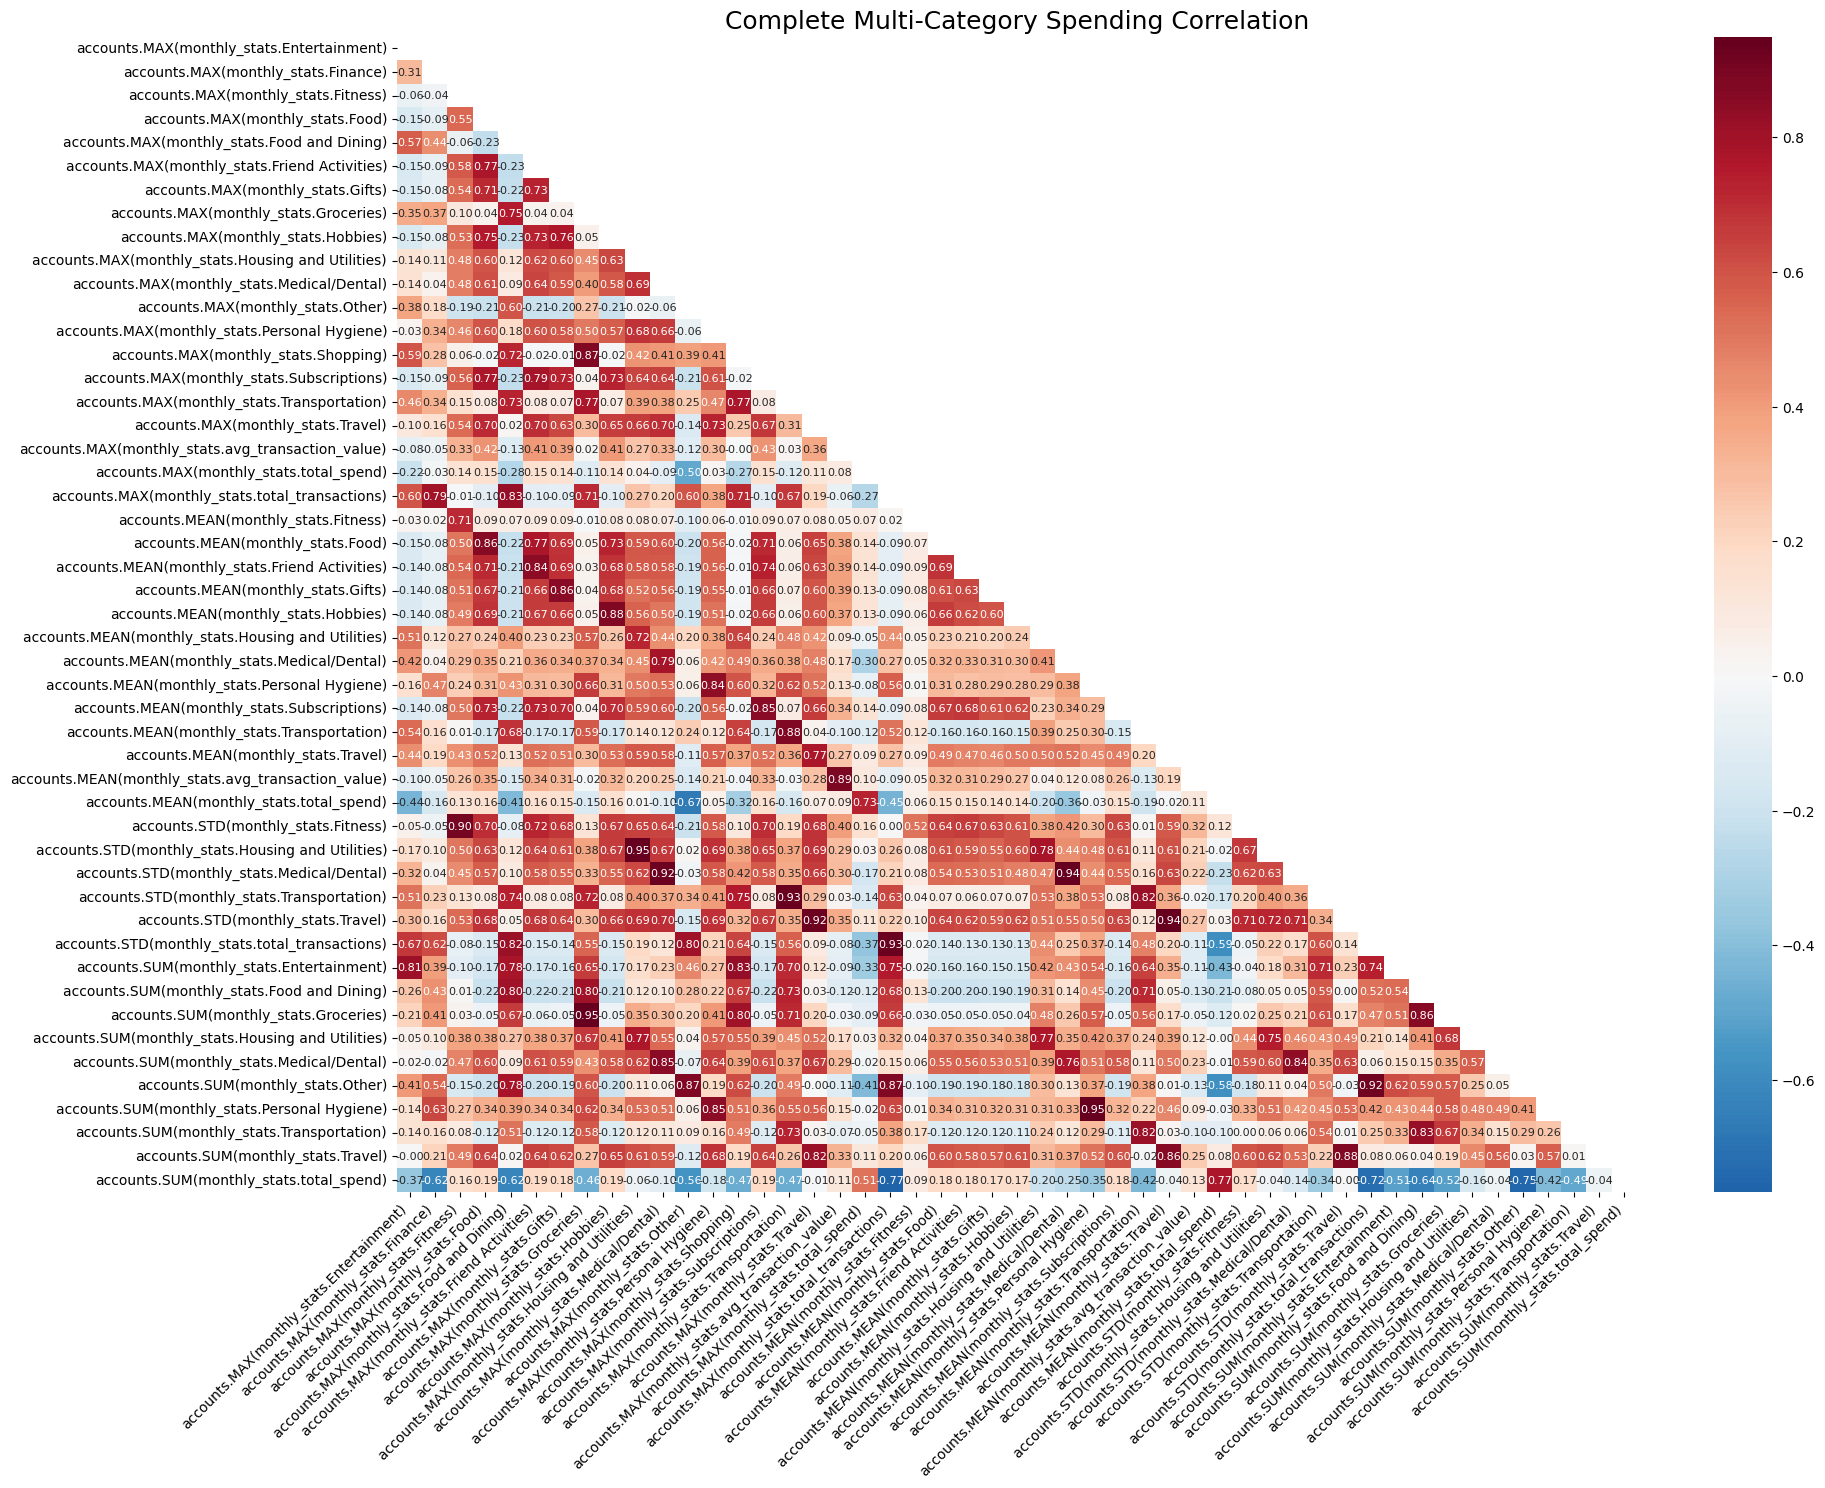

In [9]:
all_cols = fm_encoded.columns.tolist()
category_features = [c for c in all_cols if 'monthly_stats.' in c]
plt.figure(figsize=(20, 15))
corr = fm_encoded[category_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', annot_kws={"size": 8})
plt.title('Complete Multi-Category Spending Correlation', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.show()

#### Correlation Heatmap for individual users (Ex. 3 users)

>USR601Ie

There is a perfect correlation (1.00) between **Shopping** and the user's total_amount, largest, and amount_sum. This indicates that this user's largest financial outlays are almost exclusively retail-based.

**Travel** also shows a strong link (0.53) to total spending, suggesting that when this user isn't shopping, they are likely making high-value travel bookings.

The *day_of_month_mean* shows a consistent negative correlation with major categories like **Transportation** (-0.37), **Shopping** (-0.30), and **Food** (-0.34). As the day of the month increases, spending in these areas decreases. This suggests the user handles their primary expenses immediately after receiving their paycheck at the start of the month.

This user’s **Groceries** (0.06) and **Food** (-0.05) spending have almost no relationship with the weekend. Spending on **Fitness** and **Personal Hygiene** actually trends toward the weekdays, indicating these are part of a disciplined Monday-Friday work/life routine rather than weekend leisure.

A high correlation of 0.69 exists between **Gifts** and **FItness**, which is an outlier habit. This suggests that for this specific user, social obligations (gifts) often occur in tandem with their fitness schedule or community.

>USR784ar

This user has a strong correlation (0.55) between their **Medical/Dental** expenses and their total_amount/largest spends. This suggests that health-related costs are the primary drivers of their biggest financial months. While **Shopping** is still correlated with total spend (0.69), it is significantly lower than the perfect 1.00 seen in the previous user. This indicates that shopping is just one part of their financial picture, not the sole driver.

The *day_of_month_mean* shows a negative correlation with **Shopping** (-0.41). As the day of the month increases, shopping spending goes down. This user handles their "wants" early. Interestingly, **Food** (0.26) has a positive correlation with the day of the month. This suggests that as they run out of grocery money or supplies toward the end of the month, their spending on food actually increases—a classic sign of "replenishment" spending right before the next payday.

This user has very strong positive correlations with *is_weekend_sum* for **Fitness** (0.49) and **Personal Hygiene** (0.50). They likely hit the gym and handle their personal care shopping on Saturdays and Sundays. Their transportation spending (-0.11) has a slight negative correlation with the weekend, suggesting they may have a commute-heavy job during the week and stay local on weekends.

There is a strong correlation (0.80) between **Fitness** and **Friend Activities**. This user doesn't just work out alone; their social life is built around their fitness routine. They likely participate in group classes, sports leagues, or gym sessions with friends.

>USR821Id

There is a very strong correlation (0.59) between **Housing and Utilities** and their total monthly spend. This indicates that home-related costs are the primary anchor of their budget. **Groceries** also show a high correlation (0.55) with total spending, suggesting their "big" months are defined by stocking up on household essentials.

*day_of_month_mean* has a positive correlation with Personal Hygiene (0.35) and Medical/Dental (0.29). This user tends to handle maintenance and health tasks toward the middle or end of the month, likely after their primary housing and grocery bills are settled at the start.

This user has widespread positive correlations with *is_weekend_sum* across **Groceries** (0.44), **Housing** (0.28), and **Hobbies** (0.37). They are a clear "Weekend Tasker," utilizing Saturdays and Sundays to manage the household and engage in personal interests.  

A notable correlation of 0.45 exists between **Gifts** and **Transportation**. This suggests travel for this user is often linked to social obligations or visiting others to deliver gifts.


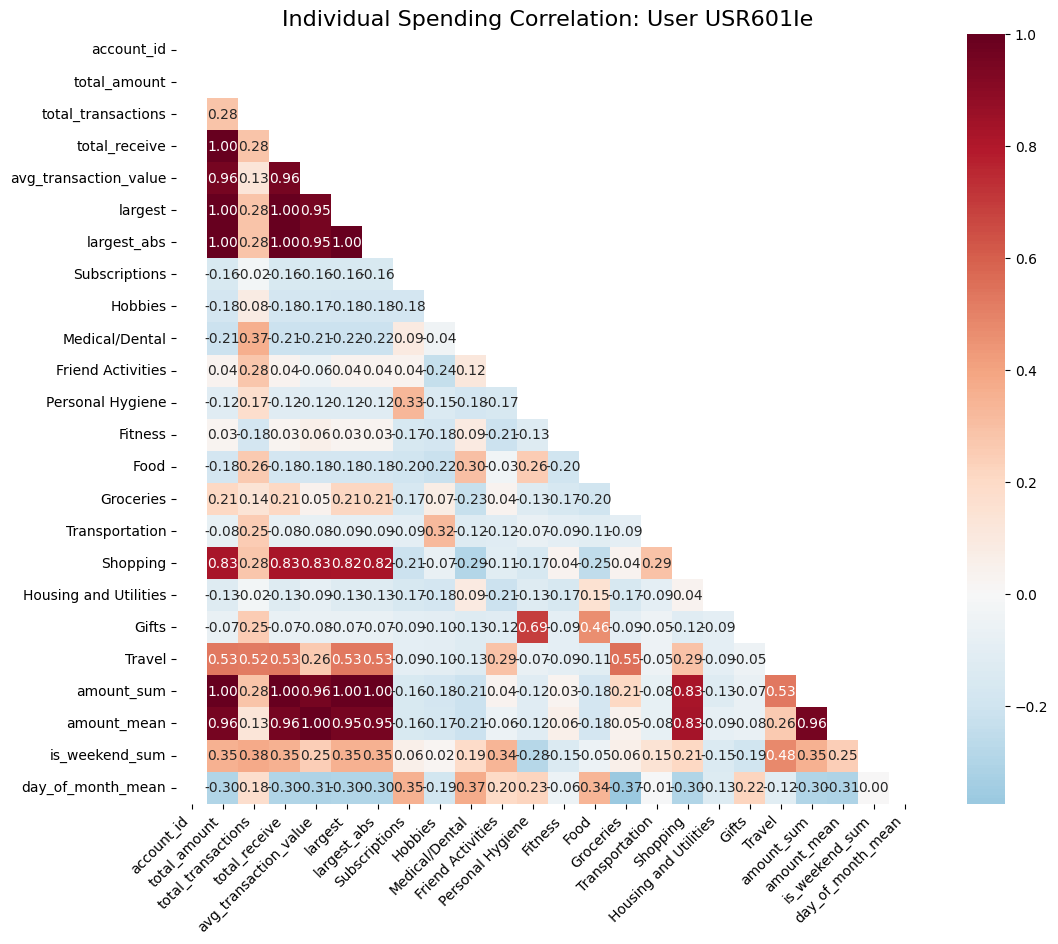

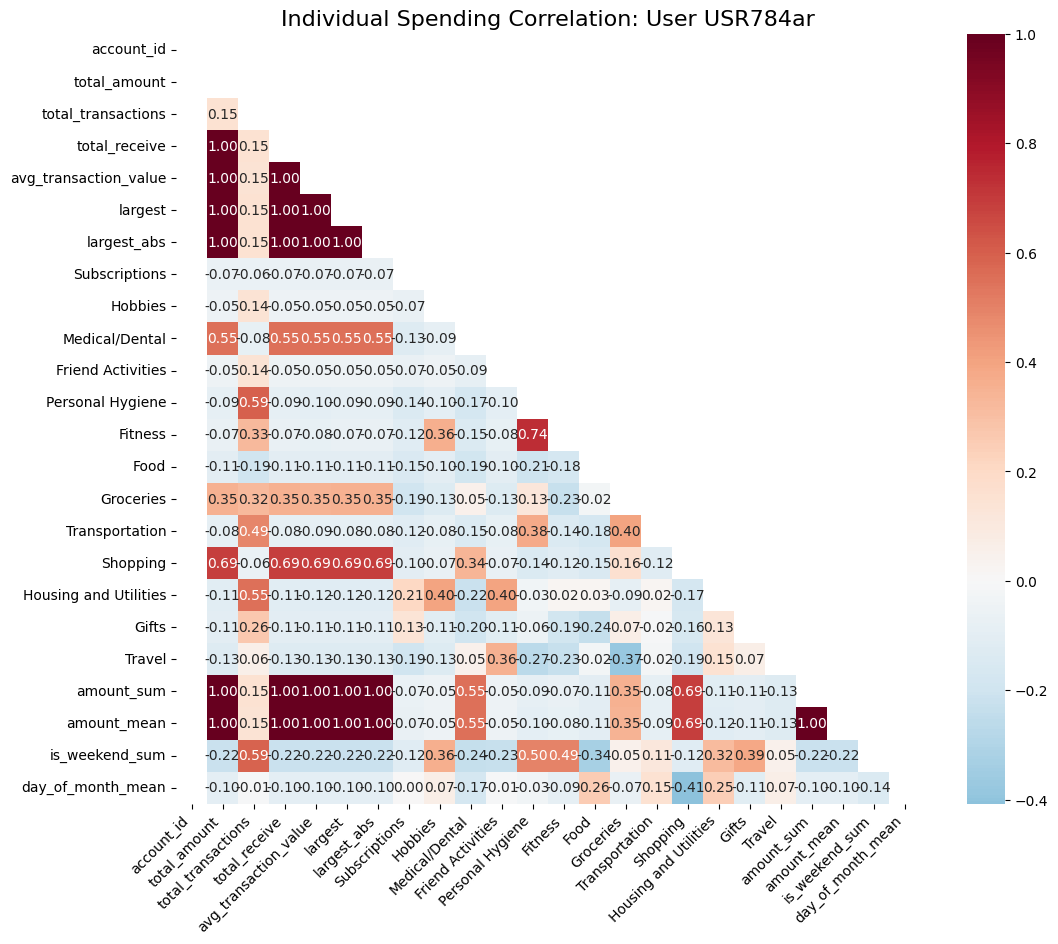

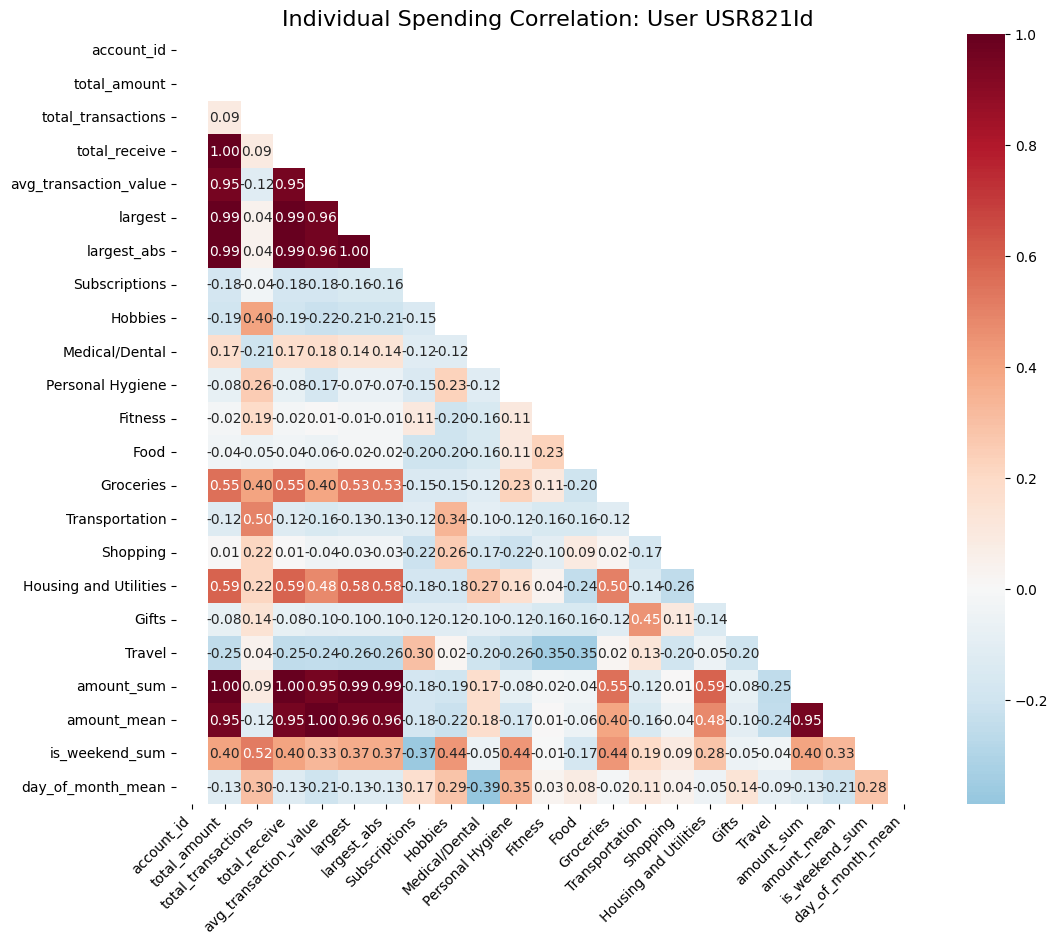

In [ ]:
sample_users = users_df.head(3)

for _, user_row in sample_users.iterrows():
    uid = user_row.name if 'user_id' not in users_df.columns else user_row['user_id']
    acc_id = user_row['account_id']
    
    user_history = monthly_stats_df[monthly_stats_df['account_id'] == acc_id].copy()
    user_trans = transactions_df[transactions_df['account_id'] == acc_id].copy()
    
    user_trans['is_weekend'] = user_trans['date'].dt.weekday >= 5
    user_trans['day_of_month'] = user_trans['date'].dt.day
    
    time_summary = user_trans.groupby(user_trans['date'].dt.to_period('M')).agg({
        'amount': ['sum', 'mean'],
        'is_weekend': 'sum',
        'day_of_month': 'mean'
    })
    time_summary.columns = ['_'.join(col).strip() for col in time_summary.columns.values]
    
    user_history['month_period'] = user_history['month_start_date'].dt.to_period('M')
    user_history.set_index('month_period', inplace=True)
    
    plot_df = pd.concat([user_history, time_summary], axis=1)

    numeric_plot_df = plot_df.select_dtypes(include=[np.number])

    numeric_plot_df = numeric_plot_df.loc[:, (numeric_plot_df != 0).any(axis=0)]

    if not numeric_plot_df.empty:
        plt.figure(figsize=(12, 10))
        user_corr = numeric_plot_df.corr()
        
        mask = np.triu(np.ones_like(user_corr, dtype=bool))
        
        sns.heatmap(user_corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
        plt.title(f'Individual Spending Correlation: User {uid}', fontsize=16)
        plt.xticks(rotation=45, ha='right')
        plt.show()
    else:
        print(f"Not enough numeric data to plot for User {uid}")